# 这是房地产市场洞察项目
1. 导入库
2. 导入数据
3. 数据概览
4. 数据清洗
5. 新数据特征构造
6. 问题分析及可视化

### 1.导入库

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# rcParams['font.sans-serif'] = ['STHeiti']  # 给macOS用
rcParams['font.family'] = 'Noto Sans CJK JP'  # 给linux用


### 2. 导入数据

In [3]:
df = pd.read_csv('../pandas/data/house_sales.csv')
df.tail()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
106113,鹤岗,南山区,73㎡,中层（共6层）,九州新建小区,12万,黑龙江,2室1厅,东西向,1644元/㎡,NaN,https://hegang.esf.fang.com/chushou/16_201235.htm
106114,鹤岗,-鹤岗市兴安区,70㎡,低层（共7层）,滨河南小区,21万,黑龙江,2室1厅,南北向,3000元/㎡,NaN,https://hegang.esf.fang.com/chushou/16_201234.htm
106115,鹤岗,-鹤岗市兴安区,70㎡,低层（共7层）,滨河南小区,21万,黑龙江,2室1厅,南北向,3000元/㎡,NaN,https://hegang.esf.fang.com/chushou/16_201234.htm
106116,鹤岗,工农区,64㎡,高层（共6层）,鹤岗市工农区原消防队三号楼,15万,黑龙江,2室1厅,南北向,2344元/㎡,NaN,https://hegang.esf.fang.com/chushou/16_201236.htm
106117,鹤岗,工农区,64㎡,高层（共6层）,鹤岗市工农区原消防队三号楼,15万,黑龙江,2室1厅,南北向,2344元/㎡,NaN,https://hegang.esf.fang.com/chushou/16_201236.htm


### 3. 数据概览

In [4]:
print('总记录数:', len(df))
print('总字段数量：', len(df.columns))
df.info()

总记录数: 106118
总字段数量： 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106118 entries, 0 to 106117
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   city        106118 non-null  object
 1   address     104452 non-null  object
 2   area        105324 non-null  object
 3   floor       104024 non-null  object
 4   name        105564 non-null  object
 5   price       105564 non-null  object
 6   province    106118 non-null  object
 7   rooms       104036 non-null  object
 8   toward      105240 non-null  object
 9   unit        105564 non-null  object
 10  year        57736 non-null   object
 11  origin_url  105564 non-null  object
dtypes: object(12)
memory usage: 9.7+ MB


### 4. 数据清洗

### 4.1 缺失值的处理

In [5]:
# 删除无用的数据列
df.drop(columns='origin_url', inplace=True)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建
1,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建
2,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建
3,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37㎡,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建


In [6]:
# 检查是否有缺失值
df.isna().sum()

# 删除缺失值数据
df.dropna(inplace=True)
print('删除后的数据还剩：', len(df))

删除后的数据还剩： 57520


In [7]:
# 检查重复值
df.duplicated().sum()

# 删除重复值
df.drop_duplicates(inplace=True)
print('删除后的数据还剩：', len(df))

删除后的数据还剩： 28104


In [8]:
# 表格中表示房屋面积的都带有单位㎡，删除单位方便后续进行计算
df['area'] = df['area'].str.replace('㎡', '').astype(float)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46万,安徽,2室1厅,南向,9200元/㎡,2019年建
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158万,安徽,4室2厅,南向,13167元/㎡,2012年建


In [9]:
# 价格要去掉单位万
df['price'] = df['price'].str.replace('万', '').astype(float)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222元/㎡,2013年建
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895元/㎡,2019年建
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649元/㎡,2017年建
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200元/㎡,2019年建
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167元/㎡,2012年建


In [10]:
# 房屋朝向类型转换
df['toward'] = df['toward'].astype('category')

In [11]:
# 每平米的价格去掉元/㎡
df['unit'] = df['unit'].str.replace('元/㎡', '').astype(float)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013年建
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019年建
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017年建
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019年建
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012年建


In [12]:
# 建造年份需要处理
df['year'] = df['year'].str.replace('年建', '').astype(int)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012


### 4.2 异常值的处理

In [13]:
# 面积的异常
print('面积太小房屋：\n', df[df['area'] < 20])
print('面积太大的房屋：\n', df[df['area'] > 600])

df = df[(df['area'] > 20) & (df['area'] < 600)]

面积太小房屋：
        city                address   area     floor     name  price province  \
102      合肥         新省府-包河大道与南京路交口  11.00  中层（共27层）   招商·雍华府   22.0       安徽   
980      天津         体育馆街-成都道与桂林路交口  11.86   高层（共1层）    成都道小区  140.0      直辖市   
6366     杭州  北干-天汇园星云地带新区金城路金鸡路交叉处  17.00  中层（共28层）  天汇园星云地带   50.0       浙江   
8388     丽水  北郭桥/白云-莲都-北郭桥/白云-汽运宿舍  17.00   高层（共1层）     汽运宿舍   48.0       浙江   
28798    毕节         黔西县-黔西南部新区教育园区  11.00  低层（共31层）    黔西阳光城   42.0       贵州   
40546    巢湖         新省府-包河大道与南京路交口  11.00  中层（共27层）   招商·雍华府   22.0       安徽   
40886    蚌埠               张公山-红旗一路  15.00   低层（共7层）   朝阳新村三村   24.5       安徽   
40892    蚌埠          淮河路-胜利东路1556号  10.00  中层（共11层）     百合公馆  132.0       安徽   
50780    泸州       蓝田-江阳区-蓝田-江阳区-蓝田  18.00   中层（共2层）   江阳区-蓝田   35.0       四川   
68686    开阳             小十字-飞山街42号  14.00  低层（共23层）    飞山街小区   13.0       贵州   
80478    孝感    中心城区-孝南-中心城区-润达壹号广场  10.00  低层（共16层）   润达壹号广场   14.0       湖北   
94170    清镇          紫林庵-飞山街中医二

In [14]:
# 房屋售价的异常处理
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['price'] > lower_bound) & (df['price'] < upper_bound)]

### 5. 新数据特征构造
- 构造新的列

In [15]:
# 区名district
df['district'] = df['address'].str.split('-').str[0]  # 取 split 之后列表里的第一个元素
df.sample(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district
50402,普宁,揭东第二中学-金凤路西侧(揭东二中对面),174.0,高层（共25层）,揭阳碧桂园,129.0,广东,4室2厅,南北向,7414.0,2018,揭东第二中学
15120,珠海,白藤头-恒裕江山汇南湖路99号(东方威尼斯公交站旁),89.1,中层（共25层）,恒裕江山汇,170.0,广东,3室2厅,南向,19080.0,2018,白藤头
102660,肇庆,大旺区-高新区大旺大道体育公园旁,97.2,中层（共32层）,龙光玖龙湖,40.1,广东,3室2厅,南北向,4126.0,2020,大旺区
38890,张家港,城西-长安南路和国泰南路交汇处,140.0,中层（共11层）,张家港百桥花园,200.0,江苏,3室2厅,南北向,14286.0,2006,城西
95106,青州,金三角-富亭街与白云路交汇处西南角,95.0,低层（共6层）,恒信华府,73.8,山东,3室1厅,南北向,7768.0,2018,金三角


In [16]:
# 楼层类型floor_type
def fun1(str1):
    if pd.isna(str1):
        return '未知'
    elif '低' in str1:
        return '低楼层'
    elif '中' in str1:
        return '中楼层'
    elif '高' in str1:
        return '高楼层'
    else:
        return '未知'


df['floor_type'] = df['floor'].apply(fun1).astype('category')
df.sample(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type
7380,昆山,花桥新城-西环路东侧、金中路北(绿地大道以南),107.00,低层（共27层）,鑫苑世家,205.0,江苏,3室2厅,南北向,19159.0,2016,花桥新城,低楼层
14358,玉林,万达广场-万达广场向东150米,143.00,低层（共32层）,金科集美天樾,92.0,广西,5室2厅,南北向,6434.0,2019,万达广场,低楼层
92798,滦县,远洋城-卫国路与朝阳道交汇处东北侧,131.00,高层（共20层）,军创凯旋城,165.0,河北,3室2厅,南北向,12595.0,2010,远洋城,高楼层
8282,句容,经济开发区-句容经济开发区华阳西路与兴源路交汇处,95.00,中层（共33层）,中骏四季阳光,72.0,江苏,3室2厅,南向,7579.0,2019,经济开发区,中楼层
71428,柳州,旧机场片区-柳太路1号(36中旁),73.77,低层（共28层）,柳工颐华城,80.0,广西,2室1厅,南北向,10845.0,2000,旧机场片区,低楼层


In [17]:
# 是否为直辖市 is_municipality
df['is_municipality'] = df['city'].apply(lambda x: 1 if x in ['北京', '天津', '上海', '重庆'] else 0)
df.sample(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,is_municipality
20250,平山,天山大街-中山东路(黄河大道)与祁连街交口北行200米,94.81,中层（共34层）,同祥城,126.0,河北,2室2厅,南北向,13290.0,2014,天山大街,中楼层,0
105734,连江,五四北板块-正荣府华林路以北晋安六小旁,83.00,高层（共7层）,正荣府,120.0,福建,3室2厅,南北向,14458.0,2000,五四北板块,高楼层,0
66860,揭阳,鱼湖-揭阳市榕城区渔湖镇望江北路中段,128.00,低层（共28层）,恒大·翡翠华庭,87.0,广东,3室2厅,南北向,6797.0,2019,鱼湖,低楼层,0
34264,泰安,光彩大市场-泰山大街与大河路立交向西100米路路南,104.00,中层（共28层）,绿地公馆,79.7,山东,3室2厅,南向,7663.0,2019,光彩大市场,中楼层,0
82376,仪征,欧尚-江阳路与维扬路交汇处东南,90.55,低层（共18层）,中集集品嘉园,152.8,江苏,2室2厅,南向,16875.0,2012,欧尚,低楼层,0


In [18]:
# 卧室数量 bedrooms
df['bedrooms'] = df['rooms'].str.split('室').str[0].astype(int)
df.sample(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,is_municipality,bedrooms
98868,新郑,郑州一中-中原路与桐柏路交叉口南100米路西,63.0,中层（共30层）,国贸公馆,86.0,河南,2室1厅,东向,13651.0,2011,郑州一中,中楼层,0,2
89220,定兴,保定七中-天鹅路与乐凯大街交叉口东行100米路南,78.0,高层（共7层）,天鹅南区,85.0,河北,2室2厅,南北向,10897.0,2000,保定七中,高楼层,0,2
31052,金湖,生态新城-绿地世纪城翔宇南道9号,155.0,高层（共21层）,绿地世纪城,180.0,江苏,4室2厅,南向,11613.0,2015,生态新城,高楼层,0,4
34522,巫山,化龙桥-化龙桥瑞天路138号(原化龙桥嘉陵路),61.0,中层（共33层）,重庆天地雍江悦庭,120.0,重庆,1室2厅,北向,19672.0,2012,化龙桥,中楼层,0,1
17036,望城,高桥-汇都公寓五一村万家丽路长沙市交通局旁,127.0,中层（共33层）,汇都公寓,113.8,湖南,3室2厅,南向,8961.0,2010,高桥,中楼层,0,3


In [19]:
# 客厅数量 livingrooms
df['livingrooms'] = df['rooms'].str.extract(r'(\d+)厅').astype(int)
df.sample(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,is_municipality,bedrooms,livingrooms
57756,阳曲,真武路-真武路68号(西区);真武路69号(东区),134.00,高层（共18层）,太原恒大绿洲,177.0,山西,3室2厅,南北向,13209.0,2014,真武路,高楼层,0,3,2
95060,青州,奥体中心-北宫街与友爱路交叉口北50米,115.00,高层（共18层）,鸢都新城,79.8,山东,3室2厅,南北向,6939.0,2014,奥体中心,高楼层,0,3,2
100448,盐城,盐都-海润尊品世纪大道646号(神龙汽车站东100,84.35,低层（共17层）,海润尊品,95.0,江苏,2室2厅,南北向,11263.0,2010,盐都,低楼层,0,2,2
35150,泰安,高铁新区-长城路堰北立交桥西南方向,97.00,高层（共30层）,开元盛世硕园,79.5,山东,3室2厅,南北向,8196.0,2021,高铁新区,高楼层,0,3,2
19094,晋州,上庄-槐安路与获铜路交口南行500米,106.00,中层（共32层）,龙泉花园东区,82.0,河北,2室2厅,南向,7736.0,2004,上庄,中楼层,0,2,2


In [20]:
# 楼龄 building_age
df['building_age'] = 2026 - df['year']
df.sample(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,is_municipality,bedrooms,livingrooms,building_age
20164,平山,铜冶-永红路86号(红旗南大街与学院路交叉口西行5,90.00,高层（共30层）,安联青年城,118.0,河北,2室2厅,南北向,13111.0,2012,铜冶,高楼层,0,2,2,14
28894,毕节,黔西县-同心商贸城对面,139.00,中层（共31层）,同心商贸城,53.0,贵州,4室2厅,南北向,3813.0,2019,黔西县,中楼层,0,4,2,7
84632,巴彦,市政府-欧美亚世界阳光龙祥路与祥安北大街交叉口东南角,115.67,高层（共7层）,欧美亚世界阳光,99.8,黑龙江,2室2厅,南北向,8628.0,2006,市政府,高楼层,0,2,2,20
22502,玉山,亿升广场-永利滨江御景滨江西路88号(双塔公园对面),116.00,中层（共5层）,永利滨江御景,95.0,江苏,3室2厅,南向,8190.0,2010,亿升广场,中楼层,0,3,2,16
68766,开阳,三桥-兴隆枫丹白鹭云岩三桥改茶路165号,160.00,中层（共8层）,兴隆枫丹白鹭,117.8,贵州,4室2厅,南北向,7362.0,2011,三桥,中楼层,0,4,2,15


In [21]:
# 价格分段 price_labels
df['price_labels'] = pd.cut(df['price'], bins=4, labels=['低价', '中等价', '高价', '豪华'])
df.sample(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,is_municipality,bedrooms,livingrooms,building_age,price_labels
57796,阳曲,胜利街-胜利东街东沿200米,144.0,中层（共28层）,富力城,170.0,山西,3室2厅,南北向,11806.0,2012,胜利街,中楼层,0,3,2,14,高价
94642,清远,东城-清远市沿江路26-27号,110.0,中层（共21层）,御水龙庭,63.5,广东,3室2厅,东南向,5773.0,2014,东城,中楼层,0,3,2,12,低价
35354,泰安,岱岳广场-政府沿府东路向北300米,95.5,低层（共5层）,泰山新湖绿园,120.0,山东,2室2厅,南北向,12565.0,2014,岱岳广场,低楼层,0,2,2,12,中等价
3324,德化,桥南片区-中骏蓝湾半岛泉州桥南片区兴霞路(转盘往晋江方,129.0,中层（共32层）,中骏蓝湾半岛,235.0,福建,4室2厅,南北向,18217.0,2015,桥南片区,中楼层,0,4,2,11,豪华
105352,长春,"远达大街-远达大街2999号(远达大街以西,宜良路以南",148.0,中层（共11层）,保利百合香湾,130.0,吉林,3室2厅,南北向,8784.0,2011,远达大街,中楼层,0,3,2,15,中等价


### 6. 问题分析及可视化

问题编号:A1
问题:哪些变量最影响房价?面积、楼层、房间数哪个影响更大?
- 分析主题:特征相关性
- 分析目标:了解房屋各特征对房价的线性影响
- 分组字段:无
- 指标/方法:皮尔逊相关系数

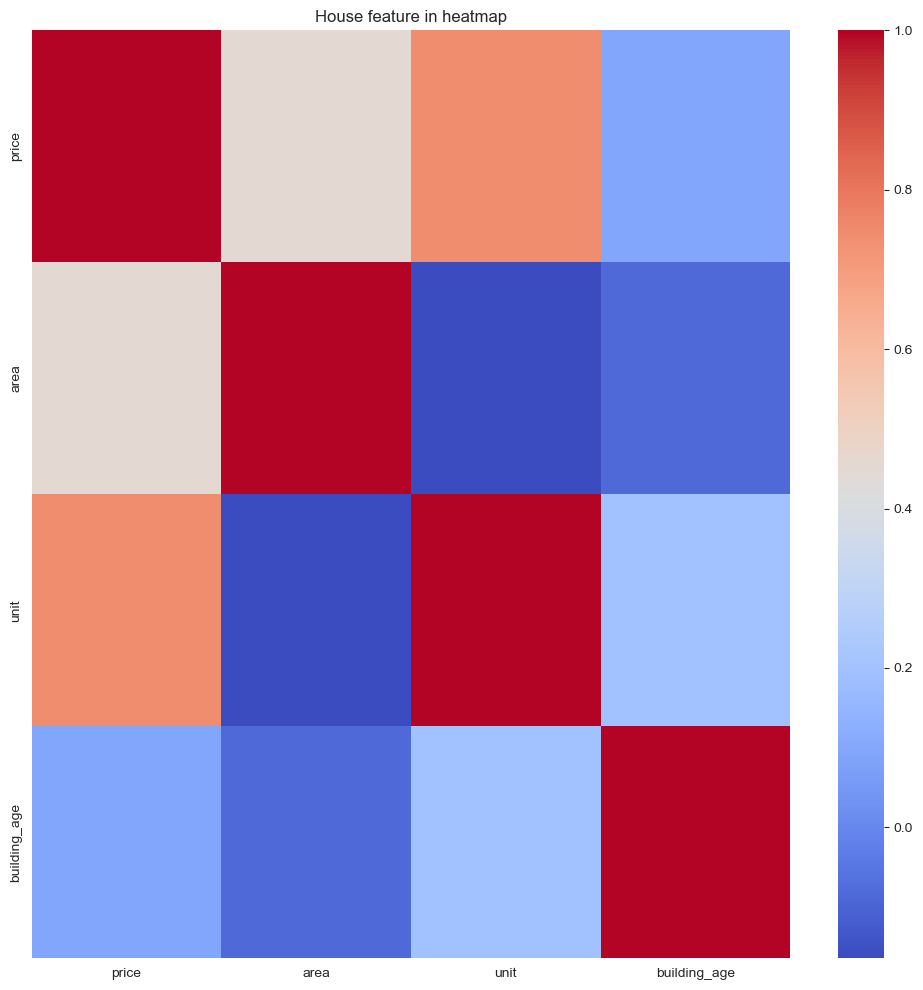

In [25]:
# 选择数据特征，计算相关系数
a = df[['price', 'area', 'unit', 'building_age']].corr()
# 对房价影响最大的几个因素
a['price'].sort_values(ascending=False)[1:]
# 画相关性的热力图
plt.figure(figsize=(10, 10))
sns.heatmap(a, cmap='coolwarm')
plt.title('House feature in heatmap')
plt.tight_layout()

问题编号:A2
问题:全国房价总体分布是怎样的?
- 分析主题:描述性统计
- 分析目标:概览数值型字段的分布特征
- 分组字段:无
- 指标/方法:平均数/中位数/四分位数/标准差

In [26]:
df.describe()

,area,price,unit,year,is_municipality,bedrooms,livingrooms,building_age
count,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000
mean,103.755810,117.208370,11610.131012,2013.072240,0.008800,2.714444,1.848556,12.927760
std,33.995994,60.967675,5824.245273,6.019342,0.093399,0.800768,0.407353,6.019342
min,21.000000,9.000000,1000.000000,1976.000000,0.000000,0.000000,0.000000,3.000000
25%,85.005000,72.000000,7587.000000,2011.000000,0.000000,2.000000,2.000000,9.000000
50%,100.000000,103.000000,10312.000000,2015.000000,0.000000,3.000000,2.000000,11.000000
75%,123.000000,150.000000,14184.000000,2017.000000,0.000000,3.000000,2.000000,15.000000
max,470.000000,306.000000,85288.000000,2023.000000,1.000000,9.000000,12.000000,50.000000


(array([ 3650., 10135.,  6490.,  3174.,  1703.,   983.]),
 array([  9. ,  58.5, 108. , 157.5, 207. , 256.5, 306. ]),
 <BarContainer object of 6 artists>)

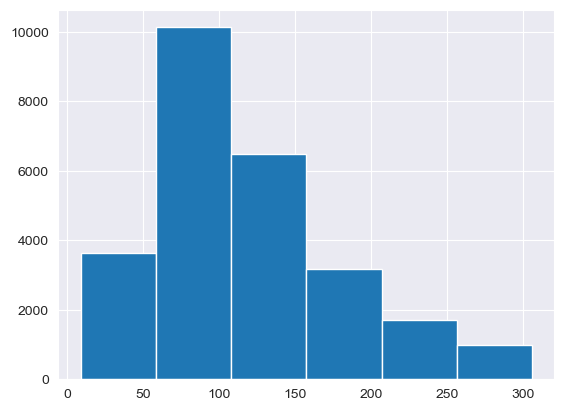

In [28]:
# 房价分布的直方图
plt.subplot(111)
plt.hist(df['price'], bins=6)


<Axes: xlabel='price', ylabel='Count'>

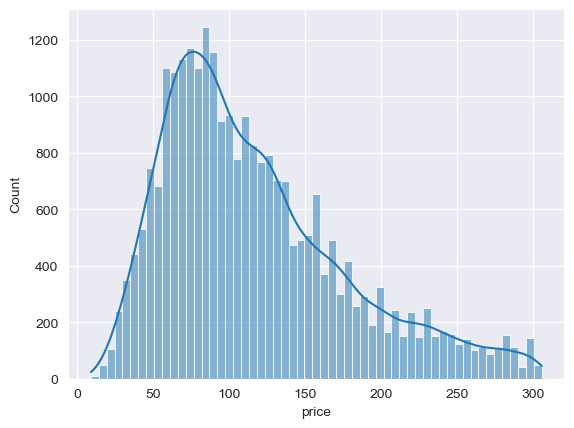

In [31]:
sns.histplot(data=df, x='price', kde=True)

问题编号:A6
问题:南北向是否真比单一朝向贵?贵多少?
- 分析主题:朝向溢价
- 分析目标:评估不同朝向的价格差异
- 分组字段: toward
- 指标/方法:方差分析/多重比较

In [34]:
df.groupby('toward').agg({
    'price': ['mean', 'median'],
    'unit': 'median',
    'building_age': 'mean',
})

/var/folders/s0/4j3j3lq56196zlq61f_r6ykw0000gn/T/ipykernel_3982/1639256807.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('toward').agg({


price            unit building_age
              mean median   median         mean
toward                                         
东北向     114.555333  100.0  12198.0    13.609524
东南向     115.542608  105.0  10864.0    11.951745
东向      110.158568   95.0  11421.0    13.761337
东西向      98.935099   82.0   9000.0    16.490066
北向       92.527907   75.5  11698.0    14.108527
南北向     119.472147  104.5  10000.0    13.073703
南向      114.555016  103.0  10759.0    12.551160
西北向     119.107594  105.0  12290.0    14.473684
西南向     139.711811  138.4  13333.0    14.452756
西向      102.662298   86.0  12528.0    14.385093

<Axes: xlabel='toward', ylabel='price'>

/Users/bowen/miniconda3/envs/ailab/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 19996 (\N{CJK UNIFIED IDEOGRAPH-4E1C}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/bowen/miniconda3/envs/ailab/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 21271 (\N{CJK UNIFIED IDEOGRAPH-5317}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/bowen/miniconda3/envs/ailab/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/bowen/miniconda3/envs/ailab/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 21335 (\N{CJK UNIFIED IDEOGRAPH-5357}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/bowen/miniconda3/envs/ailab/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 35199 (\N{CJK UNIFIED IDEOGRAPH-897F}) missing from font(s) Arial.
  func(*args, **kwa

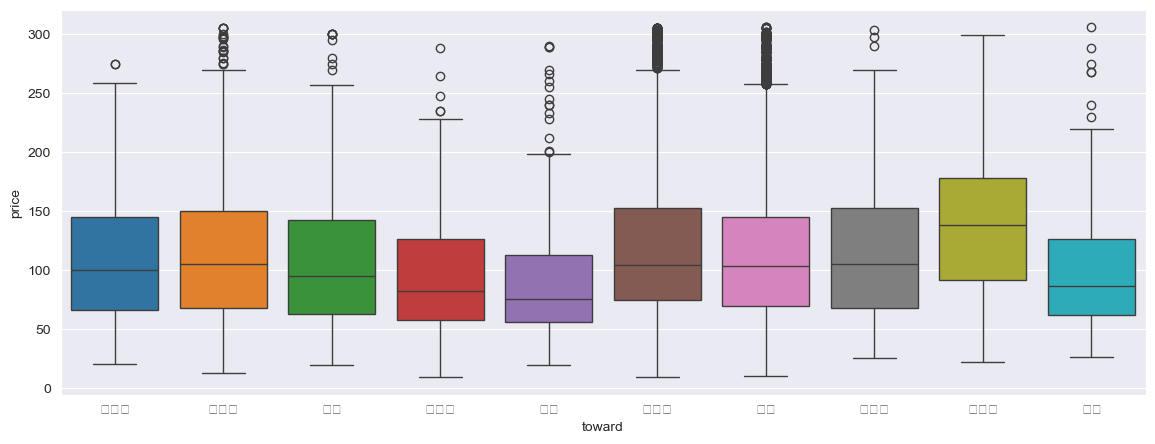

In [35]:
plt.figure(figsize=(14, 5))
sns.boxplot(x='toward', y='price', hue='toward', data=df)